In [3]:
from sklearn.datasets import fetch_openml
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


## Load the data 

In [4]:
data = fetch_openml('mnist_784', version=1, as_frame=False)
images = np.asarray(data.data)

## Add noise and train the model to reconstruct the clean image 

- Normalize image pixel values.
- Add random Gaussian noise to images.
- Train a regression model to reconstruct clean images.

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

images = images / 255.0

# إضافة ضوضاء (Noise) للصور
noise_factor = 0.3
noisy_images = images + noise_factor * np.random.randn(*images.shape)

# قص القيم عشان ما تتجاوز الحدود (0 إلى 1)
noisy_images = np.clip(noisy_images, 0., 1.)

X_train, X_test, y_train, y_test = train_test_split(
    noisy_images, images, test_size=0.2, random_state=42
)

model = KNeighborsRegressor(n_neighbors=3, n_jobs=-1)
model.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,-1


## Evaluate the model performance 

* Import the mean squared error metric from sklearn.
* Predict the clean images using the test set of noisy images.
* Calculate and print the mean squared error to assess model accuracy.

In [10]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 3.236507091860627e-16


## Plot and predict the clean image


* Import the matplotlib library for data visualization.
* Create a figure to display the clean, noisy, and predicted images side-by-side.
* Reshape the flat 784-element arrays back into 28x28 pixel images for plotting.

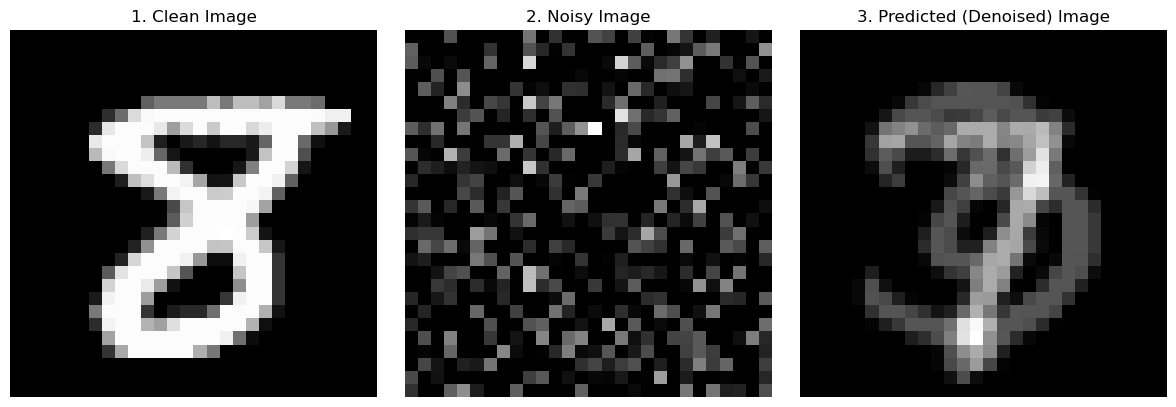

In [13]:
import matplotlib.pyplot as plt

index = 0

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(y_test[index].reshape(28, 28), cmap='gray')
axes[0].set_title("1. Clean Image")
axes[0].axis('off')

axes[1].imshow(X_test[index].reshape(28, 28), cmap='gray')
axes[1].set_title("2. Noisy Image")
axes[1].axis('off')

axes[2].imshow(y_pred[index].reshape(28, 28), cmap='gray')
axes[2].set_title("3. Predicted (Denoised) Image")
axes[2].axis('off')

plt.tight_layout()
plt.show()